In [1]:
%pip install seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Arunima\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# load dataset

df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.columns = df.columns.str.strip()  # strip extra space from column names

**Map the loan_status values as :**
* Approved : 1
* Rejected : 0

In [4]:
df['loan_status'] = df['loan_status'].str.strip()  # strip extra space from loan_status values , else giving errors
df['loan_status'] = df['loan_status'].map({'Approved': 1,'Rejected': 0})

In [5]:
df['loan_status'].head()

0    1
1    0
2    0
3    0
4    0
Name: loan_status, dtype: int64

In [6]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [7]:
y = df['loan_status'] # target col , ie , 'loan_status', extracted from df
df = df.drop(columns=['loan_status']) # drop the target col , ie , 'loan_status', from the df

In [8]:
y.isnull().sum()

np.int64(0)

# EDA

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
dtypes: int64(10), object(2)
memory usage: 400.3+ KB


In [10]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [11]:
# Check for missing values

df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
dtype: int64

 No null values , thus not needed to be handled

In [12]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

No duplicates as well !!

**Identify the numerical and categorical columns**

In [13]:
numerical = []
categorical = []

# loan_id is not an important feature for prediction, so we drop it
df = df.drop(columns=['loan_id'], errors='ignore')

for col in df.columns:
    if df[col].dtype == 'object':
        categorical.append(col)
    else:
        numerical.append(col)


print("Numerical columns:", numerical)
print("Categorical columns:", categorical)

Numerical columns: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical columns: ['education', 'self_employed']


**Plot histogram for numerical values**

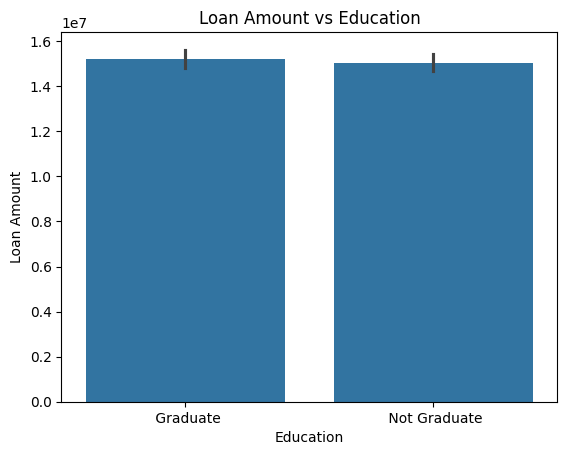

In [14]:
sns.barplot(x='education', y='loan_amount', data=df)

plt.title("Loan Amount vs Education")
plt.xlabel("Education")
plt.ylabel("Loan Amount")

plt.show()

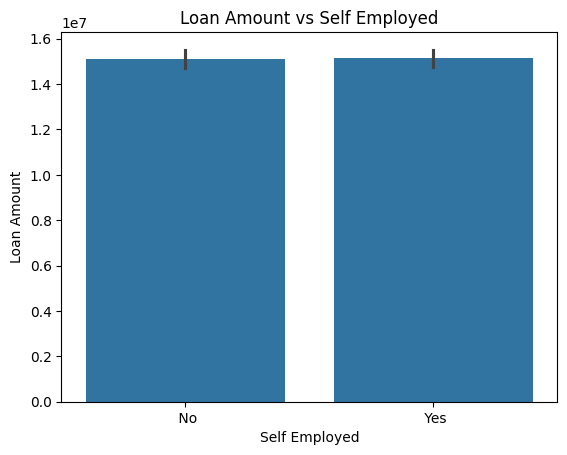

In [15]:
sns.barplot(x='self_employed', y='loan_amount', data=df)

plt.title("Loan Amount vs Self Employed")
plt.xlabel("Self Employed")
plt.ylabel("Loan Amount")

plt.show()

<Axes: xlabel='self_employed', ylabel='loan_amount'>

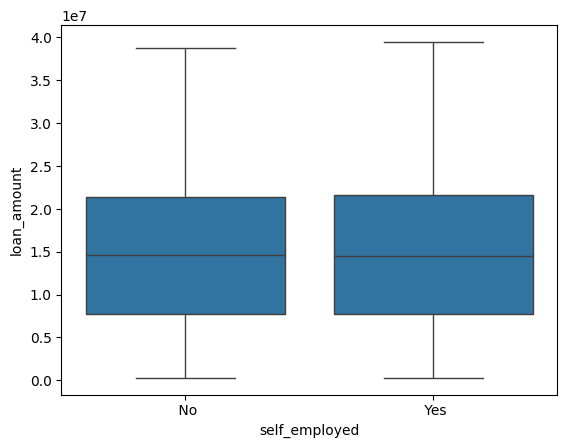

In [16]:
sns.boxplot(x='self_employed', y='loan_amount', data=df)

<Axes: xlabel='education', ylabel='loan_amount'>

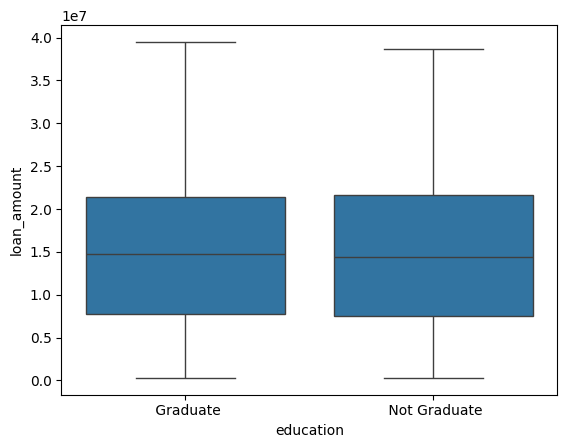

In [17]:
sns.boxplot(x='education', y='loan_amount', data=df)

Important conclusion : _Education_ and _Employment_ are not strong predictors for the loan amount asked for!

# Encode categorical features and scale the numerical features using Pipeline

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(transformers=
                              [('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
                                               ('ohe',OneHotEncoder(drop="first", handle_unknown="ignore"))]),categorical),
                                ('num',Pipeline([('imputer',SimpleImputer(strategy='mean')),
                                                ('scaler',StandardScaler())]),numerical)], remainder="passthrough")

**Train_Test_Split**

In [19]:
from sklearn.model_selection import train_test_split    

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=42)

 # Dictionary to store the models

In [20]:
models = {}

# Preprocess the data and fit model 

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


**Logistic Regression**

In [22]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['education',
                                                   'self_employed']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [23]:
y_pred_lr = lr_pipe.predict(X_test)

_Check performance_

In [24]:
from sklearn.metrics import f1_score
f1_lr = f1_score(y_test, y_pred_lr)
print("F1 Score for Logistic Regression:", round(f1_lr,3))

models['Logistic Regression'] = round(f1_lr,3)


F1 Score for Logistic Regression: 0.925


**Decision Tree Classifier**

In [25]:
dt_pipe = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['education',
                                                   'self_employed']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [26]:
y_pred_dt = dt_pipe.predict(X_test)

_Check performance_

In [27]:
from sklearn.metrics import f1_score
f1_dt = f1_score(y_test, y_pred_dt)
print("F1 Score for Decision Tree:", round(f1_dt,3))

models['Decision Tree'] = round(f1_dt,3)


F1 Score for Decision Tree: 0.988


**Random forest Classifier**

In [28]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['education',
                                                   'self_employed']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [29]:
y_pred_rf = rf_pipe.predict(X_test)

_Check performance_

In [30]:
from sklearn.metrics import f1_score
f1_rf = f1_score(y_test, y_pred_rf)
print("F1 Score for Random Forest:", round(f1_rf,3))

models['Random Forest'] = round(f1_rf,3)


F1 Score for Random Forest: 0.987


In [31]:
print("F1 Scores for all models:")
for name, model in models.items():
    print(f"{name}: {models[name]}")

F1 Scores for all models:
Logistic Regression: 0.925
Decision Tree: 0.988
Random Forest: 0.987


# Conclusion :
**Here , the best f1 score is given by Decision tree , followed closely by Random forest . Hence , the Both of them will be a good choice for testing the approval or rejection of loan status .**